In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns

In [2]:
df= pd.read_csv("heart.csv")
df

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
df = df.drop("Unnamed: 0",axis= 1)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [4]:
d= {'cp':'chest_pain_type','trestbps':'resting_bp','chol':'cholestrol','fbs':'faasting_blood_sugar','thalach':'maximum_heart_rate','exang':'exercise_induced_angina','ca':'number of major vessels'}
df.rename(columns= d,inplace=True)
df.head()

,age,sex,chest_pain_type,resting_bp,cholestrol,faasting_blood_sugar,restecg,maximum_heart_rate,exercise_induced_angina,oldpeak,slope,number of major vessels,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<Axes: xlabel='target', ylabel='count'>

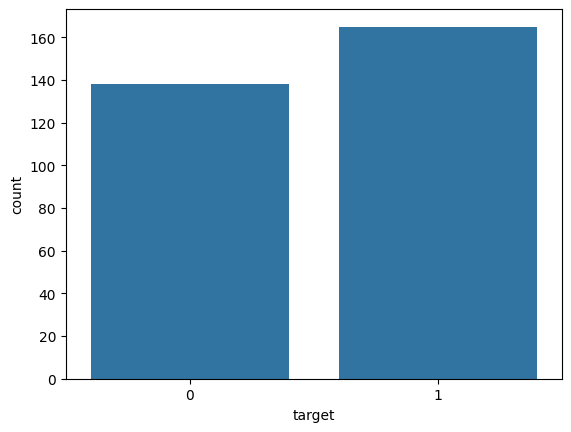

In [5]:
sns.countplot(x='target',data=df)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [7]:
X=df.drop("target",axis= 1)
y = df.target


In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [9]:
model=[LogisticRegression(),SVC(kernel="linear"),RandomForestClassifier(n_estimators=100,max_depth=5)]

for m in model:
    model=m
    model= model.fit(X_train,y_train)
    print("MODEL:",m)
    print("Training Effeciency:",model.score(X_train,y_train))
    print("testing effeciency:", model.score(X_test,y_test))
    X_train.shape


c:\Users\Hrushi\miniconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


MODEL: LogisticRegression()
Training Effeciency: 0.8679245283018868
testing effeciency: 0.8131868131868132
MODEL: SVC(kernel='linear')
Training Effeciency: 0.8820754716981132
testing effeciency: 0.8131868131868132
MODEL: RandomForestClassifier(max_depth=5)
Training Effeciency: 0.9575471698113207
testing effeciency: 0.8351648351648352


In [10]:
model = LogisticRegression()
model.fit(X_train,y_train)


c:\Users\Hrushi\miniconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [11]:
print("Training Effeciency:",model.score(X_train,y_train))
print("testing effeciency:", model.score(X_test,y_test))

Training Effeciency: 0.8679245283018868
testing effeciency: 0.8131868131868132


In [12]:
ypred = model.predict(X_test)
ypred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1], dtype=int64)

In [ ]:
print("ACCURACY :",accuracy_score(y_test,ypred))
print("RECALL: :",recall_score(y_test,ypred))


NameError: name 'y_pred' is not defined

In [ ]:
df.to_csv("cleaned_data.csv")


In [ ]:
import joblib
with open("Log_model.joblib","wb") as file:
    joblib.dump(model,file)